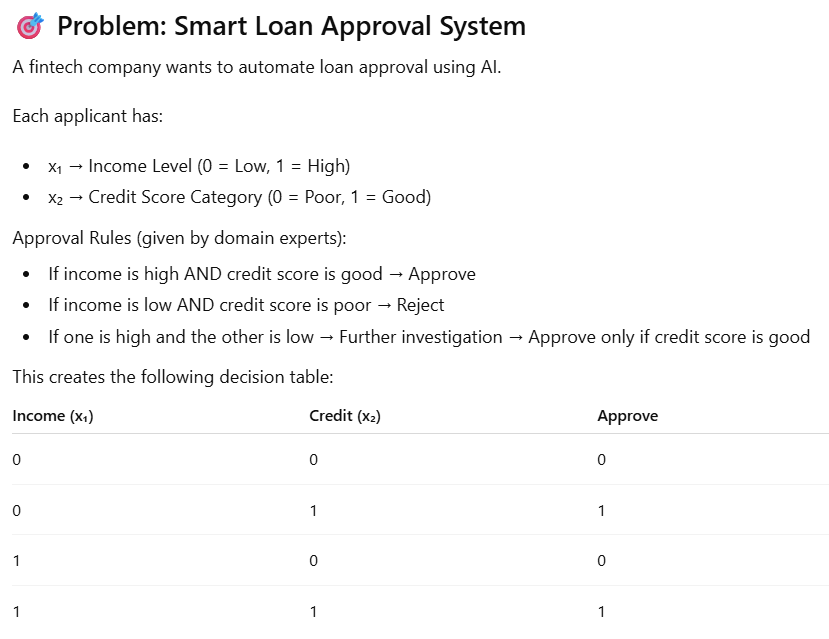
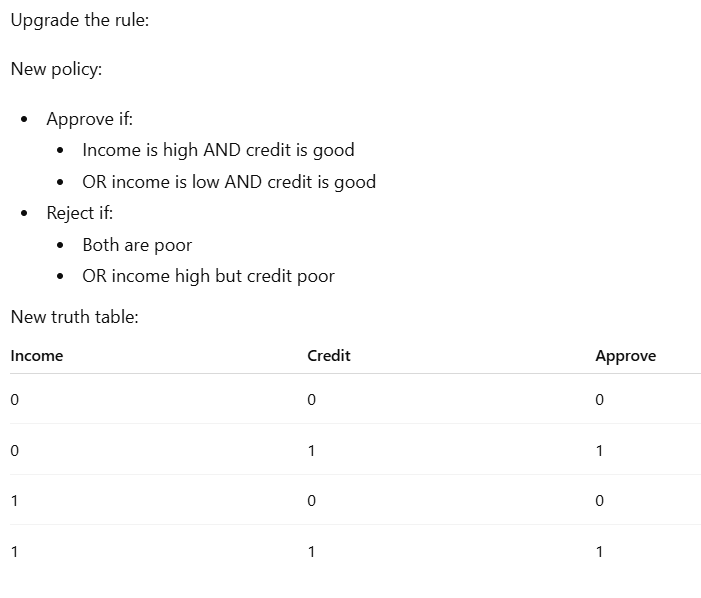
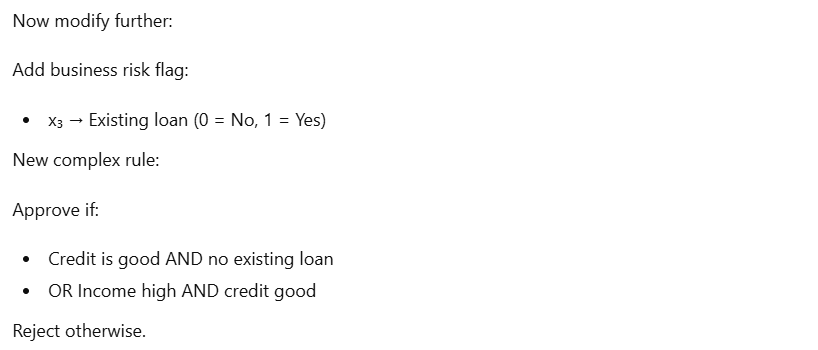
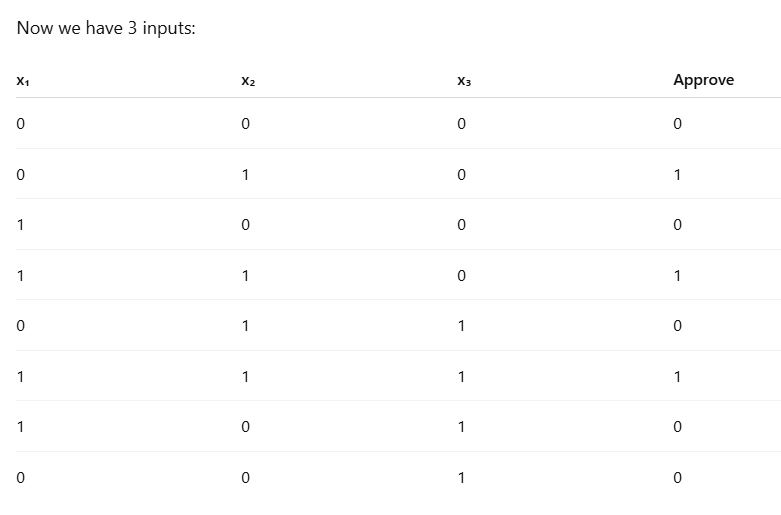
Part A – Conceptual
Is this problem linearly separable?
Can single perceptron solve it?
Why or why not?


Part B – Architecture Design
Design:
3 Inputs → 3 Hidden Neurons → 1 Output
Explain:
What feature each hidden neuron should detect.
Why hidden layer helps.

Part C – Forward Propagation
 

🌟 Part A – Conceptual
Is this problem linearly separable?

Look at the final truth table (3 inputs).

Approve = 1 for:

(0,1,0)

(1,1,0)

(1,1,1)

Everything else → 0

If you observe carefully:

Approval strongly depends on credit (x₂)
When credit = 0 → always reject
When credit = 1 → depends on other features

This can be simplified logically as:

𝐴
𝑝
𝑝
𝑟
𝑜
𝑣
𝑒
=
𝑥
2
∧
(
¬
𝑥
3
∨
𝑥
1
)
Approve=x
2
	​

∧(¬x
3
	​

∨x
1
	​

)

This is not a single straight hyperplane in 3D space.

So:

👉 Not linearly separable

Can single perceptron solve it?

❌ No.

Why?

A single perceptron can only form:

𝑤
1
𝑥
1
+
𝑤
2
𝑥
2
+
𝑤
3
𝑥
3
+
𝑏
=
0
w
1
	​

x
1
	​

+w
2
	​

x
2
	​

+w
3
	​

x
3
	​

+b=0

That is just one flat plane.

But your logic requires:

One condition for credit good & no loan

Another condition for income high & credit good

That’s like combining multiple regions — not one straight boundary.

So a single perceptron cannot represent this logic.

In [6]:
w11 = 0
w12 = 1
w13 = -1
b1 = -0.5

In [1]:
# Step activation function
def step(x):
    return 1 if x >= 0 else 0


# Dataset: (x1, x2, x3)
# x1 = Income
# x2 = Credit
# x3 = Existing Loan

data = [
    (0,0,0),
    (0,1,0),
    (1,0,0),
    (1,1,0),
    (0,1,1),
    (1,1,1),
    (1,0,1),
    (0,0,1)
]


# -------- Hidden Layer Weights --------

# n1: Credit good AND no loan
w11, w12, w13 = 0, 1, -1
b1 = -0.5

# n2: Income high AND credit good
w21, w22, w23 = 1, 1, 0
b2 = -1.5

# n3: Risk detector (loan + poor credit)
w31, w32, w33 = 0, -1, 1
b3 = -0.5


# -------- Output Layer Weights --------

w41, w42, w43 = 1, 1, -2
b4 = -0.5


print("x1 x2 x3 | Output")
print("-------------------")

for i in data:
    x1=i[0]
    x2=i[1]
    x3=i[2]
    
    # Hidden layer
    n1 = step(w11*x1 + w12*x2 + w13*x3 + b1)
    n2 = step(w21*x1 + w22*x2 + w23*x3 + b2)
    n3 = step(w31*x1 + w32*x2 + w33*x3 + b3)
    
    # Output layer
    output = step(w41*n1 + w42*n2 + w43*n3 + b4)
    
    print(x1, x2, x3, "|", output)

x1 x2 x3 | Output
-------------------
0 0 0 | 0
0 1 0 | 1
1 0 0 | 0
1 1 0 | 1
0 1 1 | 0
1 1 1 | 1
1 0 1 | 0
0 0 1 | 0
